# Test AlphaZero Tree Search

In [1]:
import numpy as np
from numpy.random import default_rng

from chess import Board
from IPython.display import Image, display

import sys

sys.path.append('../src')

import ctypes.util
print("cairo ->", ctypes.util.find_library("cairo"))

import os
os.environ['DYLD_FALLBACK_LIBRARY_PATH'] = "/opt/homebrew/lib:" + os.environ.get('DYLD_FALLBACK_LIBRARY_PATH','')
import cairosvg  # now it should find libcairo

from games.chess import KRK
from AlphaZero.alpha_zero import GameSearchTree

cairo -> None


/Users/edgarjoseandradelotero/GitHub/ChessFinalistMCTS/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step by step

### Initialize game, policy and search tree

In [2]:
seed = 4
rng = default_rng(seed)

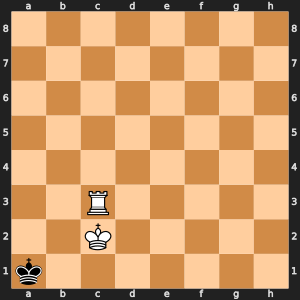

In [3]:
game = KRK()
state = game.initial_state
game.render(state)

In [4]:
from stable_baselines3.a2c import A2C

from agents.utils import ChessEncoder
from agents.random_agent import RandomAgent
from agents.random_policy import GameUniformPolicy
from games.game_utils import GymEnvFromGameAndPlayer2

random_policy = GameUniformPolicy(
    game=game,
    rng=rng,
    encoder=None
)

pl2 = RandomAgent(
    policy=random_policy,
    rng=rng
)
encoder = ChessEncoder()
env = GymEnvFromGameAndPlayer2(
    game=game,
    other_player=pl2,
    encoder=encoder
)

sbl_agent = A2C('MlpPolicy', env, verbose=0)

In [5]:
encoder.observation_space

Box(-inf, inf, (65,), float32)

In [6]:
import torch

def value_network(state):
    # Convert state to tensor
    tensor = torch.tensor(state, dtype=torch.float32)
    # Add batch dimension
    tensor = tensor.unsqueeze(dim=0)
    # Get value prediction from the policy
    with torch.no_grad():
        value = sbl_agent.policy.predict_values(tensor)
    return value

def policy_network(state):
    # Convert state to tensor
    tensor = torch.tensor(state, dtype=torch.float32)
    # Add batch dimension
    tensor = tensor.unsqueeze(dim=0)
    # Get value prediction from the policy
    with torch.no_grad():
        distribution = sbl_agent.policy.get_distribution(tensor)
        probs = distribution.distribution.probs
    return probs


result = env.reset()
state = result[0]

print(f"Value state: {value_network(state)}")
print(f"Policy: {policy_network(state)}")

Value state: tensor([[0.1096]])
Policy: tensor([[0.0331, 0.0334, 0.0335, 0.0333, 0.0334, 0.0330, 0.0335, 0.0332, 0.0333,
         0.0333, 0.0334, 0.0336, 0.0336, 0.0332, 0.0333, 0.0332, 0.0333, 0.0333,
         0.0334, 0.0334, 0.0331, 0.0335, 0.0334, 0.0334, 0.0334, 0.0330, 0.0335,
         0.0335, 0.0332, 0.0331]])


In [7]:
params = {
    "puct_constant": 1,
    "value_network": value_network,
    "policy_network": policy_network,
    "encoder": encoder,
    "n_iterations": 3,
    "rng":rng
}

state = game.initial_state

tree = GameSearchTree(
    root=state,
    game=game,
    **params
)

### Visualize root

In [8]:
print(tree.root)

State --root--
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . R . . . . .
. . K . . . . .
k . . . . . . .
Depth: 0
Reward/Visits: 1.00/1 (=1.00)



In [9]:
child = tree.root.children[11]
state = encoder.encode_obs(child.state)
state = encoder.to_array(state)
print(state)
v = value_network(state)
print(f"Value: {v}")
policy_values = policy_network(state)
print(f"Policy: {policy_values} --- {policy_values.shape}")
action_index = encoder.encode_action(tree.root.state, child.action)
print(f"Action index: {action_index}")
p = policy_values[0, action_index]
print(f"Policy value for action {child.action}: {p}")
print(child.puct(
    total_visits=1,
    p = p,
))

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 3. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 2. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
Value: tensor([[0.4849]])
Policy: tensor([[0.0333, 0.0335, 0.0333, 0.0330, 0.0334, 0.0336, 0.0335, 0.0333, 0.0335,
         0.0334, 0.0333, 0.0338, 0.0334, 0.0332, 0.0332, 0.0332, 0.0331, 0.0334,
         0.0331, 0.0333, 0.0334, 0.0333, 0.0333, 0.0332, 0.0335, 0.0331, 0.0333,
         0.0333, 0.0331, 0.0334]]) --- torch.Size([1, 30])
Action index: 23
Policy value for action c3a3: 0.03323371335864067
tensor(1.0166)


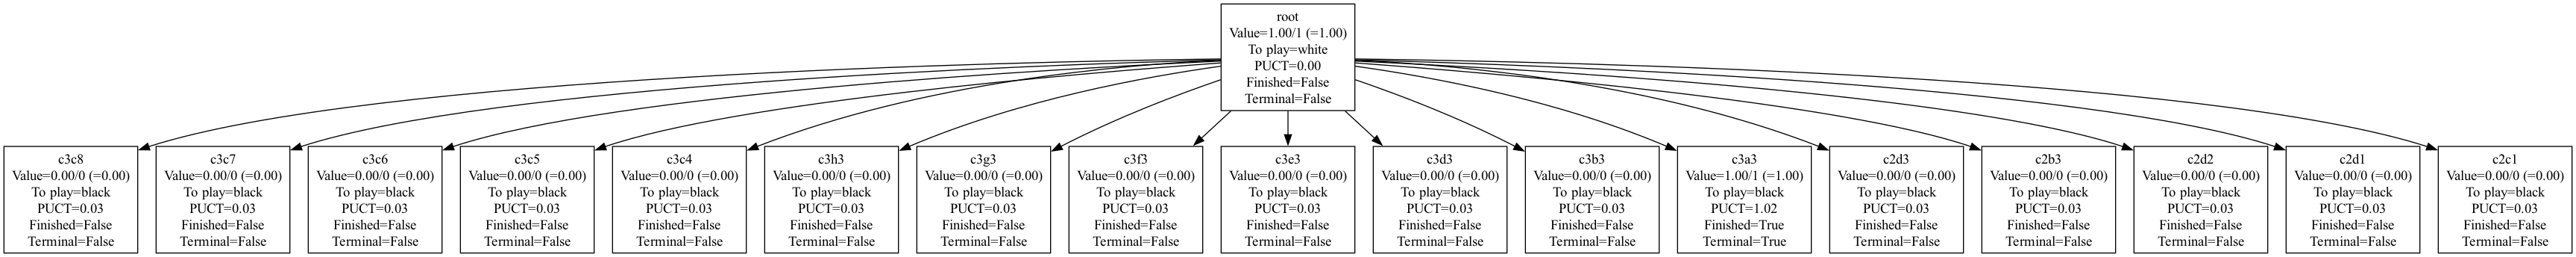

In [10]:
png_data = tree.to_pydot().create_png()
display(Image(png_data))

### Step 1: Leaf selection

In [11]:
node = tree.select_puct()
print('Selected node:')
print(node)

Selected node:
State 
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . R . . . . .
. . . K . . . .
k . . . . . . .
Depth: 1
Reward/Visits: 0.00/0 (=0.00)
From action: c2d2
Value: 0.00/0 (=0.00)



### Step 2: Leaf expansion

In [12]:
tree.expand_node(node)

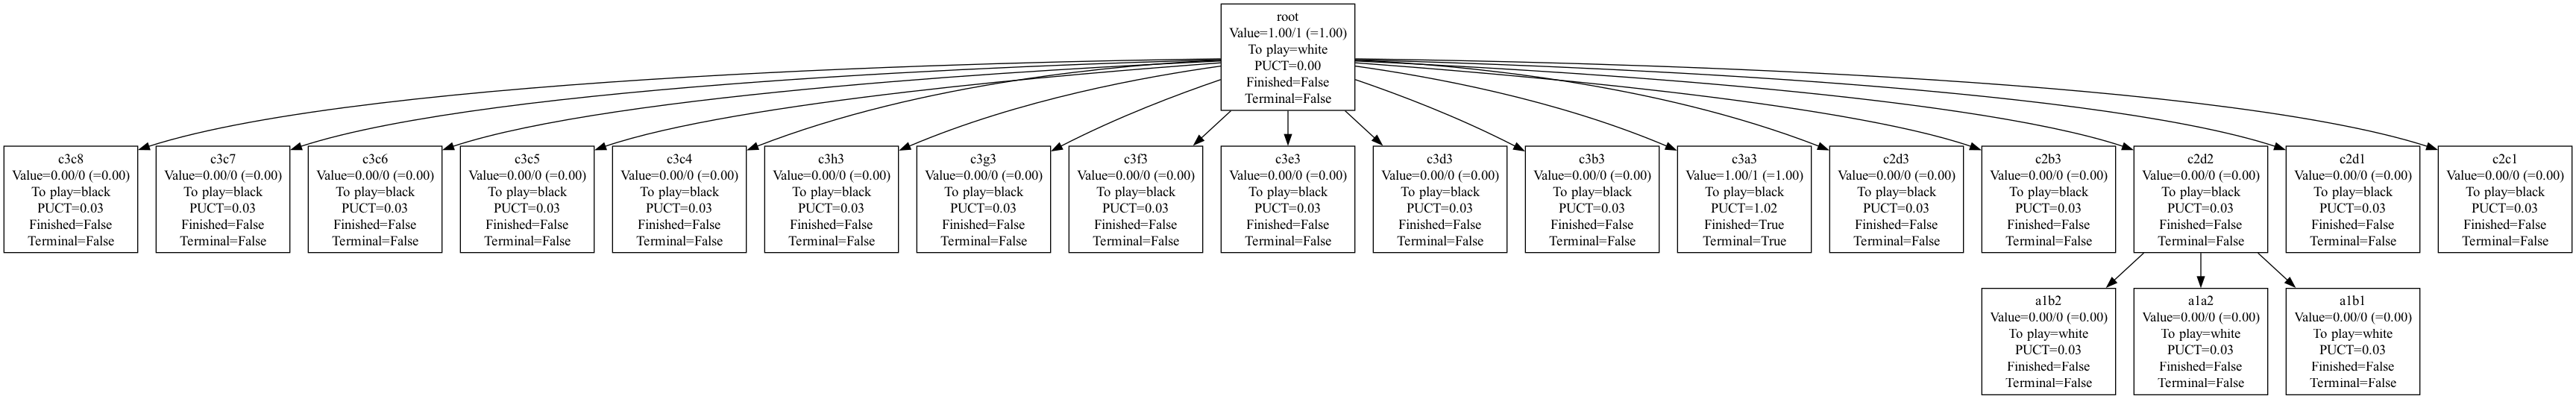

In [13]:
png_data = tree.to_pydot().create_png()
display(Image(png_data))

### Step 4: Backpropagate

In [14]:
result = tree.get_v(node)
tree.backpropagate(node, result)

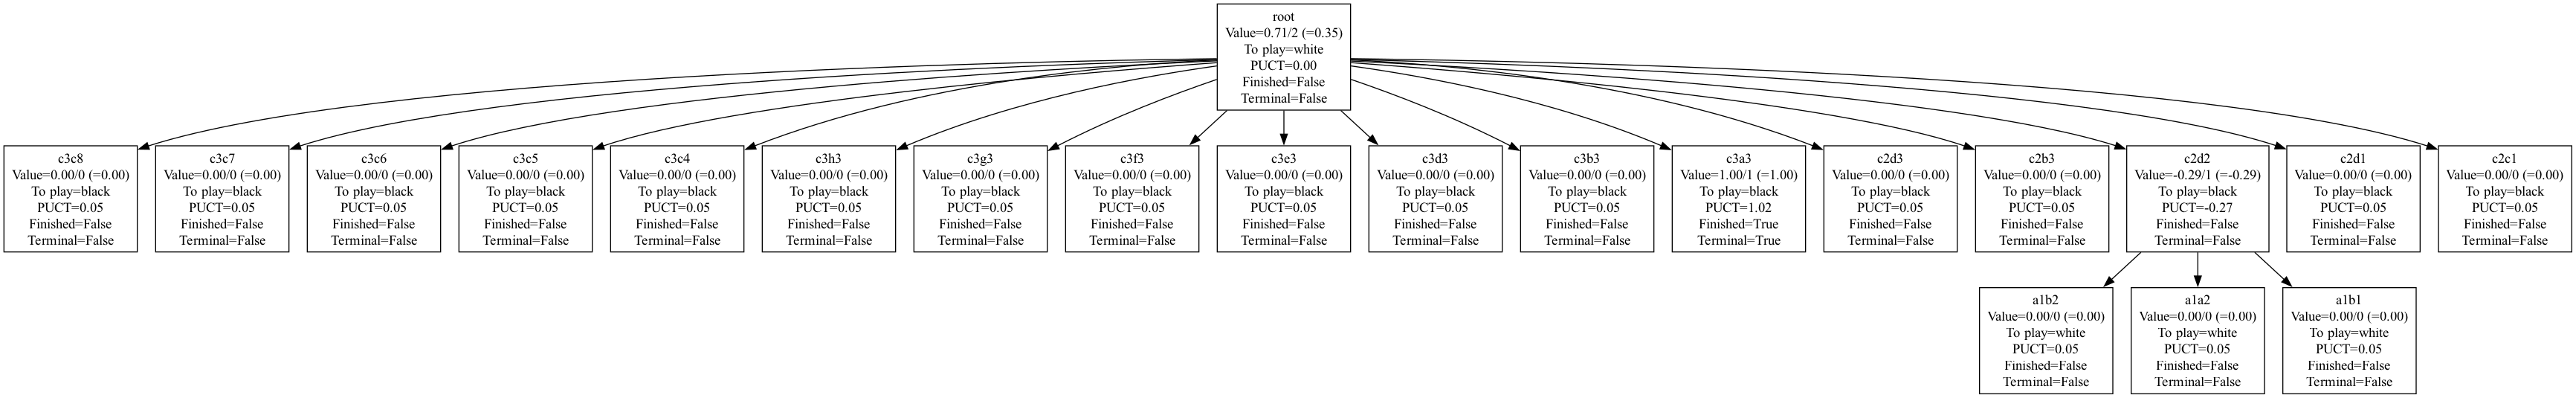

In [15]:
png_data = tree.to_pydot().create_png()
display(Image(png_data))

## All steps

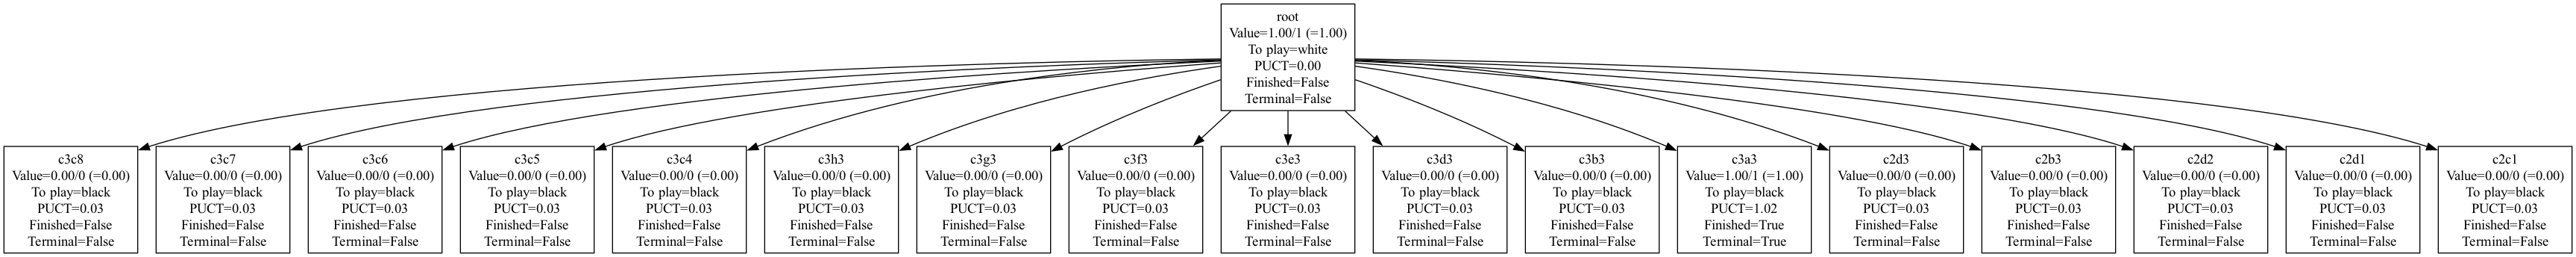

In [16]:
game = KRK()
state = game.initial_state

seed = 4
rng = default_rng(seed)

params = {
    "puct_constant": 1,
    "value_network": value_network,
    "policy_network": policy_network,
    "encoder": encoder,
    "n_iterations": 3,
    "rng":rng
}

state = game.initial_state

tree = GameSearchTree(
    root=state,
    game=game,
    **params
)

png_data = tree.to_pydot().create_png()
display(Image(png_data))


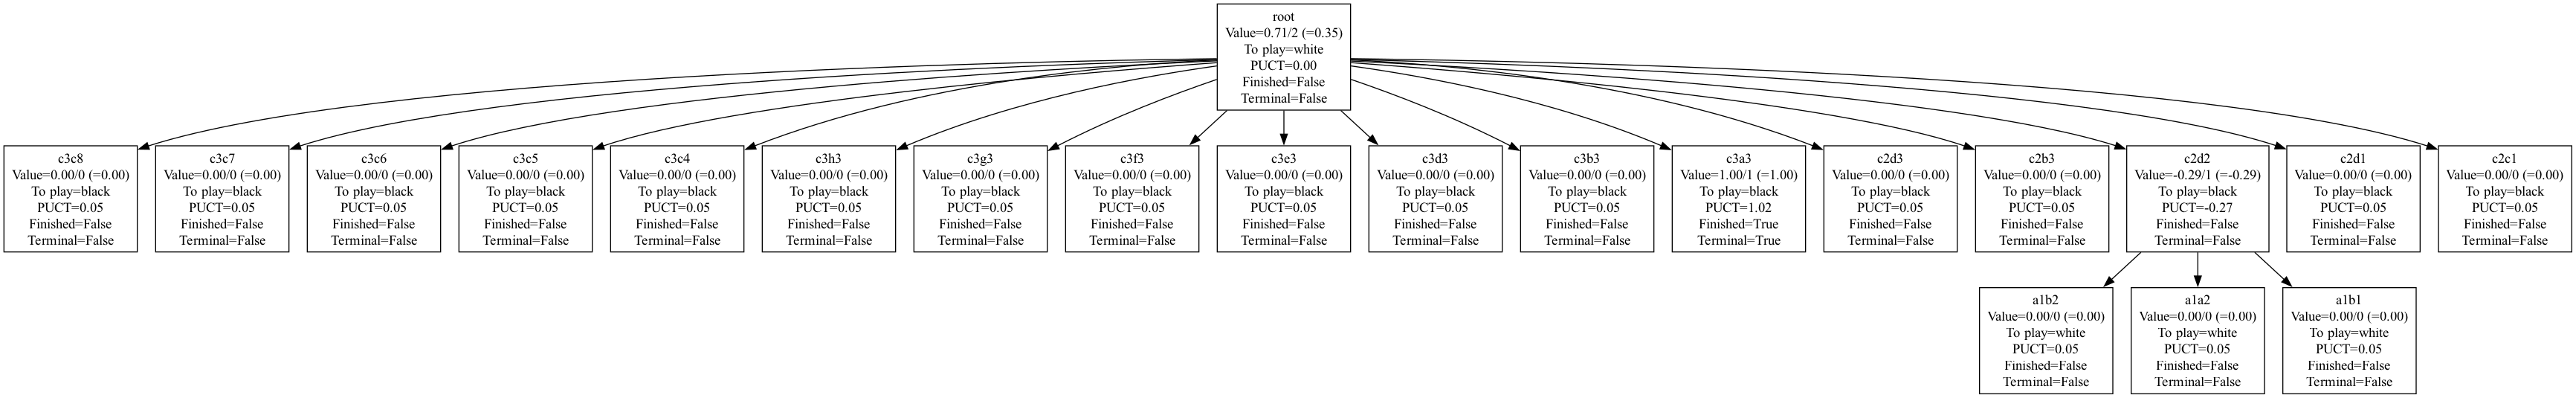

In [17]:
node = tree.select_puct()
tree.expand_node(node)
result = tree.get_v(node)
tree.backpropagate(node, result)
png_data = tree.to_pydot().create_png()
display(Image(png_data))

### Iteration

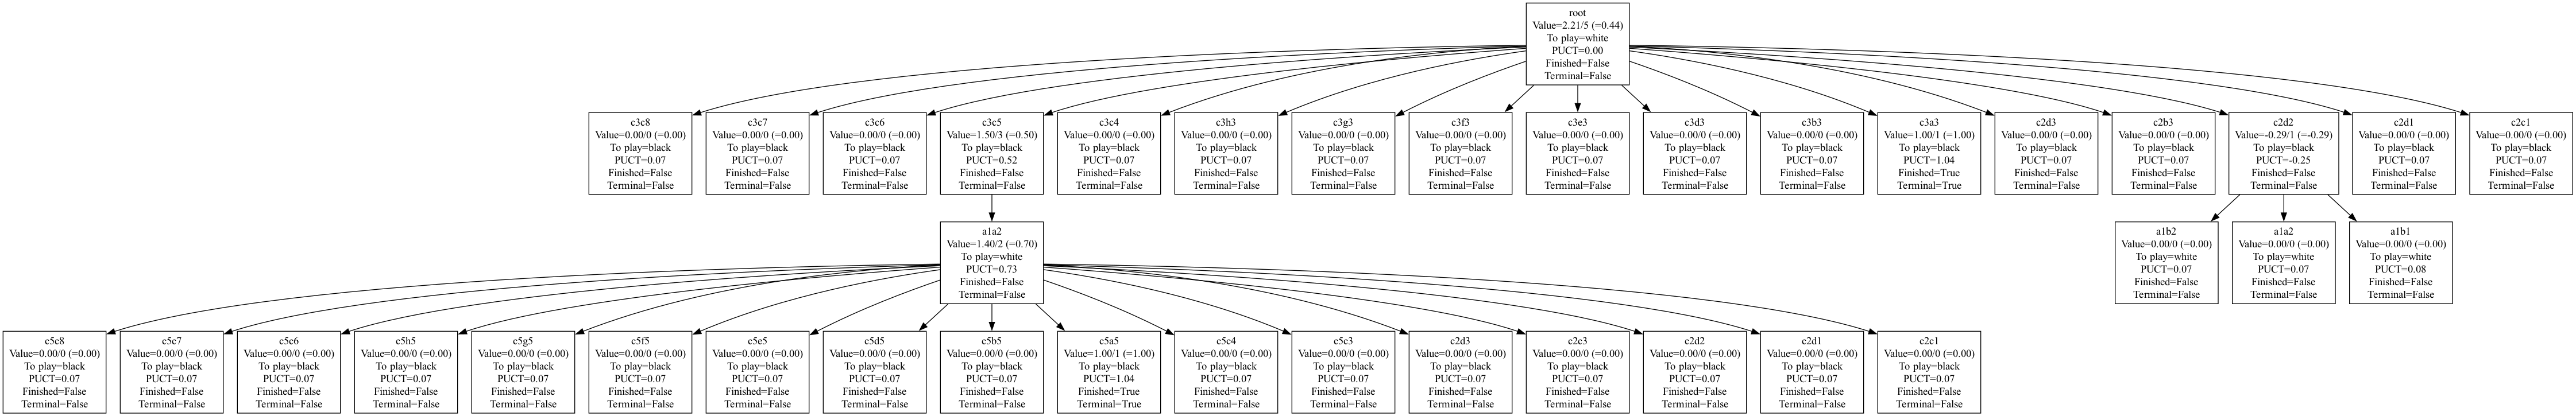

In [18]:
game = KRK()
state = game.initial_state

seed = 4
rng = default_rng(seed)

params = {
    "puct_constant": 1,
    "value_network": value_network,
    "policy_network": policy_network,
    "encoder": encoder,
    "n_iterations": 3,
    "rng":rng
}

state = game.initial_state

tree = GameSearchTree(
    root=state,
    game=game,
    **params
)

counter = 0
while counter < tree.n_iterations:

    # Step 1: Node selection
    node = tree.select_puct()
    if node is None:
        raise Exception(f"Ooops, no puct selection from node {node}")
    if node.is_fully_expanded():
        raise Exception(f"Ooops, no expansion from node {node}")

    # Step 2: Expansion
    tree.expand_node(node)

    # Step 3: Rollout
    result = tree.get_v(node)

    # Step 4: Backpropagate
    tree.backpropagate(node, result)

    counter += 1

png_data = tree.to_pydot().create_png()
display(Image(png_data))

In [19]:
best_root_action = tree.get_best_root_action()
print('Best action:', best_root_action)

Best action: c3a3


## A more difficult example

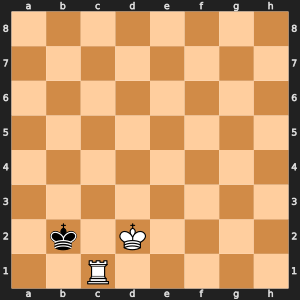

In [25]:
# Initialize game, random policy and MCTS parameters
game = KRK(start_position=3)

params = {
    "puct_constant": 1,
    "value_network": value_network,
    "policy_network": policy_network,
    "encoder": encoder,
    "n_iterations": 4,
    "rng":rng
}

state = game.initial_state

tree = GameSearchTree(
    root=state,
    game=game,
    **params
)

# Show initial state
root = game.initial_state
game.render(state)

In [27]:
tree = GameSearchTree(
    root=root,
    game=game,
    **params
)

# Show best action
best_action = tree.make_decision()
print('Best action:', best_action)

# Make transition
state = tree.game.result(tree.root.state, best_action)
if tree.game.is_terminal(state):
    game.announce_result(state)
    utility = game.utility(state)
    print('Board utility:', utility)

# Prepare for next iteration
root = tree.get_root_child_from_action(best_action)

# Render
game.render(state)

. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
. k . K . . . .
R . . . . . . .
Puct: 0.0
Children: []
finished=False


Exception: Ooops, didn't find usable best child from node
State 
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
. k . K . . . .
R . . . . . . .
Depth: 1
Reward/Visits: 0.00/0 (=0.00)
From action: c1a1
Value: 0.00/0 (=0.00)

The action history is:
['c1a1']

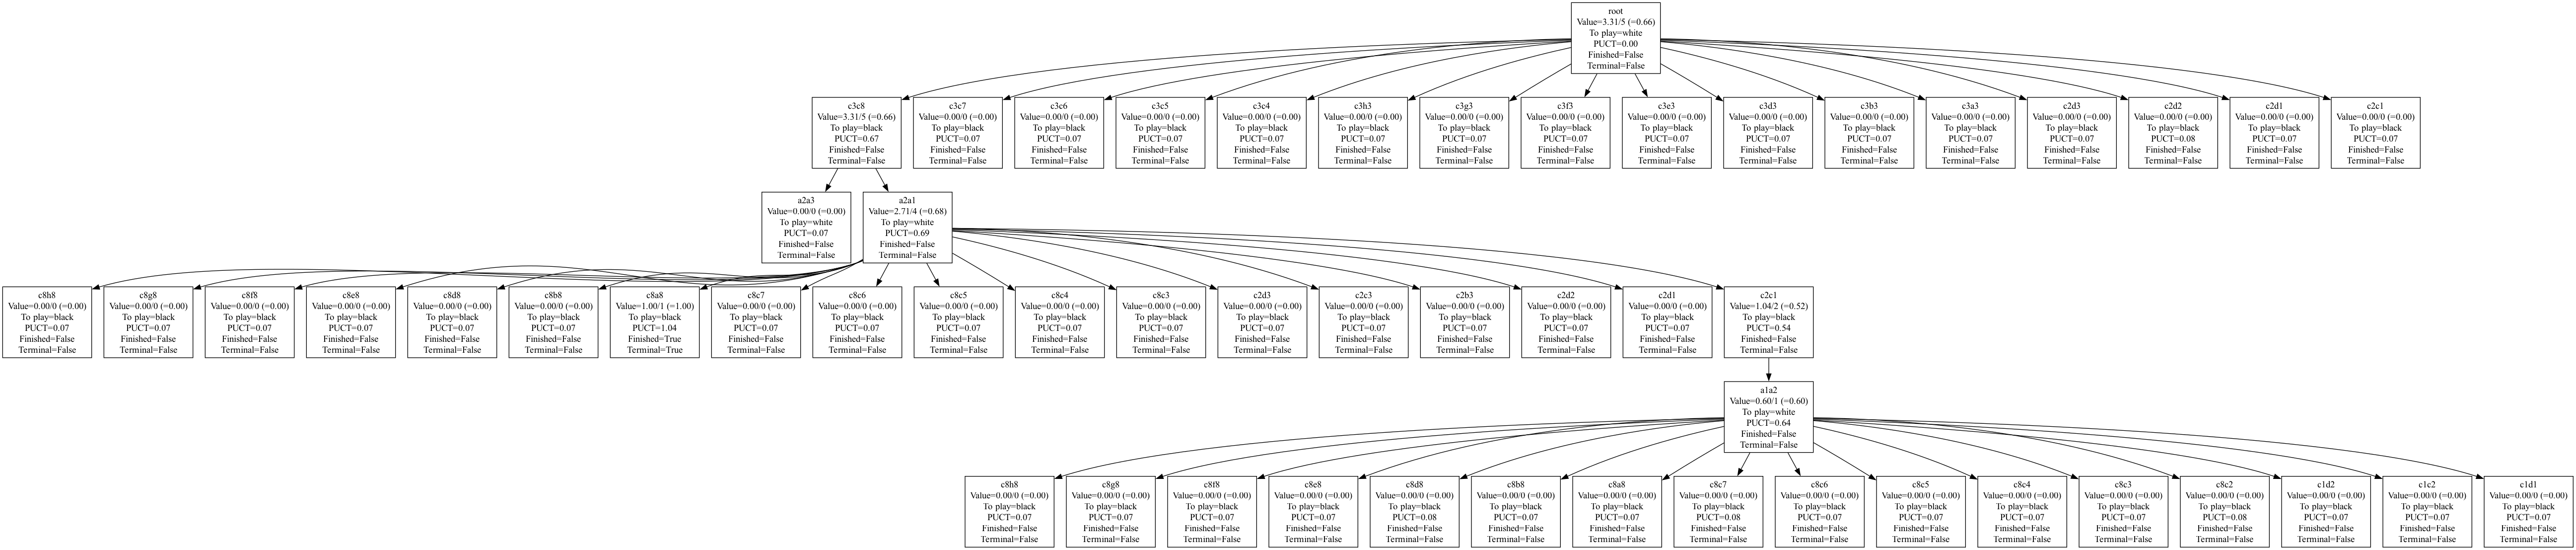

In [22]:
png_data = tree.to_pydot().create_png()
display(Image(png_data))

---